In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

# Import everything we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')

# Show first 5 rows to confirm it loaded
print(" Dataset loaded! Shape:", df.shape)
df.head()

 Dataset loaded! Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# See basic info about the dataset
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabi

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Preprocessing (Handle Missing Values)

In [4]:
# STEP 5A: Fill missing Age values with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# STEP 5B: Fill missing Embarked with the most common value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# STEP 5C: Drop the Cabin column (too many missing values - not useful)
df.drop(columns=['Cabin'], inplace=True)

# STEP 5D: Drop rows that still have any missing values
df.dropna(inplace=True)

print(" Missing values handled!")
print("Remaining missing values:\n", df.isnull().sum())

 Missing values handled!
Remaining missing values:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_4458/980098992.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_4458/980098992.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

# Encode Categorical Features

In [5]:
# Convert 'Sex' column: male=0, female=1
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])

# Convert 'Embarked' column: C=0, Q=1, S=2
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])

print(" Categorical features encoded!")
print(df[['Sex', 'Embarked']].head(10))

 Categorical features encoded!
   Sex  Embarked
0    1         2
1    0         0
2    0         2
3    0         2
4    1         2
5    1         1
6    1         2
7    1         2
8    0         2
9    0         0


# Select Features & Split the Data

In [6]:
# Choose the columns (features) we will use for prediction
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]   # Input features
y = df[target]     # What we want to predict (survived or not)

# Split into Train (70%), Validation (15%), Test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f" Data split complete!")
print(f"Training set:   {X_train.shape[0]} rows")
print(f"Validation set: {X_val.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")

 Data split complete!
Training set:   623 rows
Validation set: 134 rows
Test set:       134 rows


# Normalize/Standardize Numerical Features

In [7]:
# Standardize: makes all numbers on a similar scale (important for Logistic Regression)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # Fit on training data
X_val   = scaler.transform(X_val)         # Apply same scaling to validation
X_test  = scaler.transform(X_test)        # Apply same scaling to test

print(" Features standardized!")

 Features standardized!


# Train the Logistic Regression Model

In [8]:
# Create and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print(" Model trained successfully!")

 Model trained successfully!


# Evaluate on Validation Set

In [9]:
# Make predictions on validation set
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]  # Probability scores

print("=== Validation Set Evaluation ===")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_val, y_val_prob):.4f}")

=== Validation Set Evaluation ===
Accuracy:  0.8209
Precision: 0.8704
Recall:    0.7344
F1-Score:  0.7966
AUC:       0.9100


# Confusion Matrix (Heatmap)

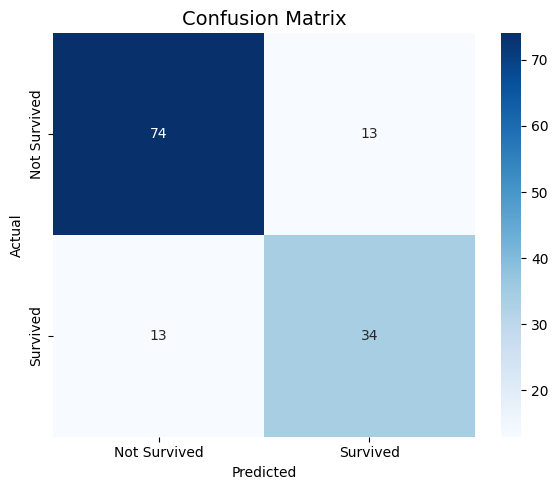

 Confusion Matrix saved!


In [10]:
# Confusion Matrix on Test Set
y_test_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(" Confusion Matrix saved!")

# All Evaluation Metrics

In [11]:
y_test_prob = model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec  = recall_score(y_test, y_test_pred)
f1   = f1_score(y_test, y_test_pred)
auc  = roc_auc_score(y_test, y_test_prob)

# Display as a nice table
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Score':  [acc, prec, rec, f1, auc]
})
metrics_df['Score'] = metrics_df['Score'].round(4)
print("=== Final Test Set Metrics ===")
print(metrics_df.to_string(index=False))

# Also show detailed classification report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=['Not Survived', 'Survived']))

=== Final Test Set Metrics ===
   Metric  Score
 Accuracy 0.8060
Precision 0.7234
   Recall 0.7234
 F1-Score 0.7234
      AUC 0.8467

=== Classification Report ===
              precision    recall  f1-score   support

Not Survived       0.85      0.85      0.85        87
    Survived       0.72      0.72      0.72        47

    accuracy                           0.81       134
   macro avg       0.79      0.79      0.79       134
weighted avg       0.81      0.81      0.81       134



# ROC Curve

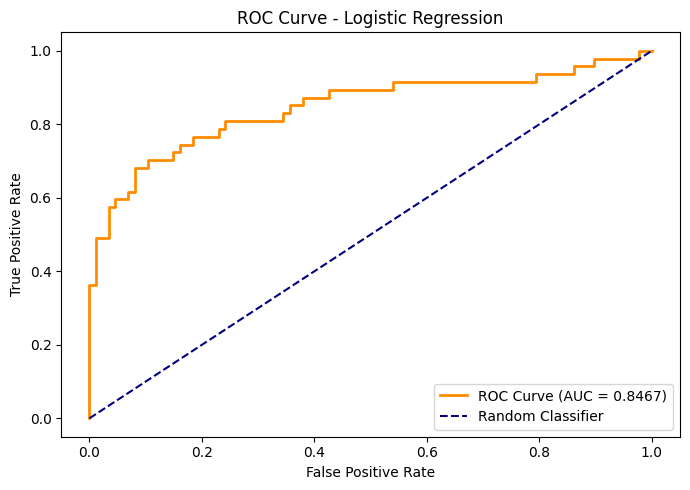

 ROC Curve saved!


In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()
print(" ROC Curve saved!")

# Sample Predictions (Actual vs Predicted + Probability)

In [13]:
# Show 15 sample predictions
sample = pd.DataFrame(X_test[:15], columns=features)
sample['Actual']      = y_test.values[:15]
sample['Predicted']   = y_test_pred[:15]
sample['Probability'] = y_test_prob[:15].round(4)

# Make it readable
sample['Actual']    = sample['Actual'].map({0: 'Not Survived', 1: 'Survived'})
sample['Predicted'] = sample['Predicted'].map({0: 'Not Survived', 1: 'Survived'})
sample['Correct?']  = (sample['Actual'] == sample['Predicted']).map({True: '✅', False: '❌'})

print("=== Sample Predictions (Actual vs Predicted) ===")
print(sample[['Actual', 'Predicted', 'Probability', 'Correct?']].to_string(index=False))

=== Sample Predictions (Actual vs Predicted) ===
      Actual    Predicted  Probability Correct?
Not Survived Not Survived       0.1314        ✅
Not Survived Not Survived       0.1348        ✅
    Survived     Survived       0.6113        ✅
Not Survived Not Survived       0.2202        ✅
Not Survived Not Survived       0.2891        ✅
Not Survived     Survived       0.5605        ❌
Not Survived Not Survived       0.1042        ✅
Not Survived Not Survived       0.1009        ✅
Not Survived Not Survived       0.1345        ✅
Not Survived Not Survived       0.1010        ✅
    Survived     Survived       0.8337        ✅
    Survived     Survived       0.9177        ✅
Not Survived Not Survived       0.4578        ✅
Not Survived     Survived       0.7135        ❌
Not Survived Not Survived       0.1056        ✅
